In [44]:
# GAURAV CHAUHAN
# E23CSEU0554

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="Outcome"
)

df = X.copy()
df["Outcome"] = y

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (569, 31)


In [5]:
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
print("Number of rows:", df.shape[0])
print("Number of features:", X.shape[1])

Number of rows: 569
Number of features: 30


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [8]:
summary = df.describe().T

display(summary)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [9]:
print("Mean:")
display(
    df.drop(columns="Outcome").mean()
)

Mean:


,0
mean radius,14.127292
mean texture,19.289649
mean perimeter,91.969033
mean area,654.889104
mean smoothness,0.096360
mean compactness,0.104341
mean concavity,0.088799
mean concave points,0.048919
mean symmetry,0.181162
mean fractal dimension,0.062798


In [10]:
print("Median:")
display(
    df.drop(columns="Outcome").median()
)

Median:


,0
mean radius,13.370000
mean texture,18.840000
mean perimeter,86.240000
mean area,551.100000
mean smoothness,0.095870
mean compactness,0.092630
mean concavity,0.061540
mean concave points,0.033500
mean symmetry,0.179200
mean fractal dimension,0.061540


In [11]:
print("Standard Deviation:")
display(
    df.drop(columns="Outcome").std()
)

Standard Deviation:


,0
mean radius,3.524049
mean texture,4.301036
mean perimeter,24.298981
mean area,351.914129
mean smoothness,0.014064
mean compactness,0.052813
mean concavity,0.079720
mean concave points,0.038803
mean symmetry,0.027414
mean fractal dimension,0.007060


In [12]:
missing_values = df.isnull().sum()

print("Missing values:")
display(missing_values)

print(
    "Total missing values:",
    missing_values.sum()
)

Missing values:


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


Total missing values: 0


In [13]:
missing_values = df.isnull().sum()

print("Missing values:")
display(missing_values)

print(
    "Total missing values:",
    missing_values.sum()
)

Missing values:


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


Total missing values: 0


In [14]:
df = df.drop_duplicates()

print(
    "Shape after removing duplicates:",
    df.shape
)

Shape after removing duplicates: (569, 31)


In [15]:
features = df.drop(
    columns="Outcome"
)

Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (
    (features < lower) |
    (features > upper)
).sum()

print("Outliers in each feature:")
display(outliers)

Outliers in each feature:


,0
mean radius,14
mean texture,7
mean perimeter,13
mean area,25
mean smoothness,6
mean compactness,16
mean concavity,18
mean concave points,10
mean symmetry,15
mean fractal dimension,15


In [16]:
features = df.drop(
    columns="Outcome"
)

Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (
    (features < lower) |
    (features > upper)
).sum()

print("Outliers in each feature:")
display(outliers)

Outliers in each feature:


,0
mean radius,14
mean texture,7
mean perimeter,13
mean area,25
mean smoothness,6
mean compactness,16
mean concavity,18
mean concave points,10
mean symmetry,15
mean fractal dimension,15


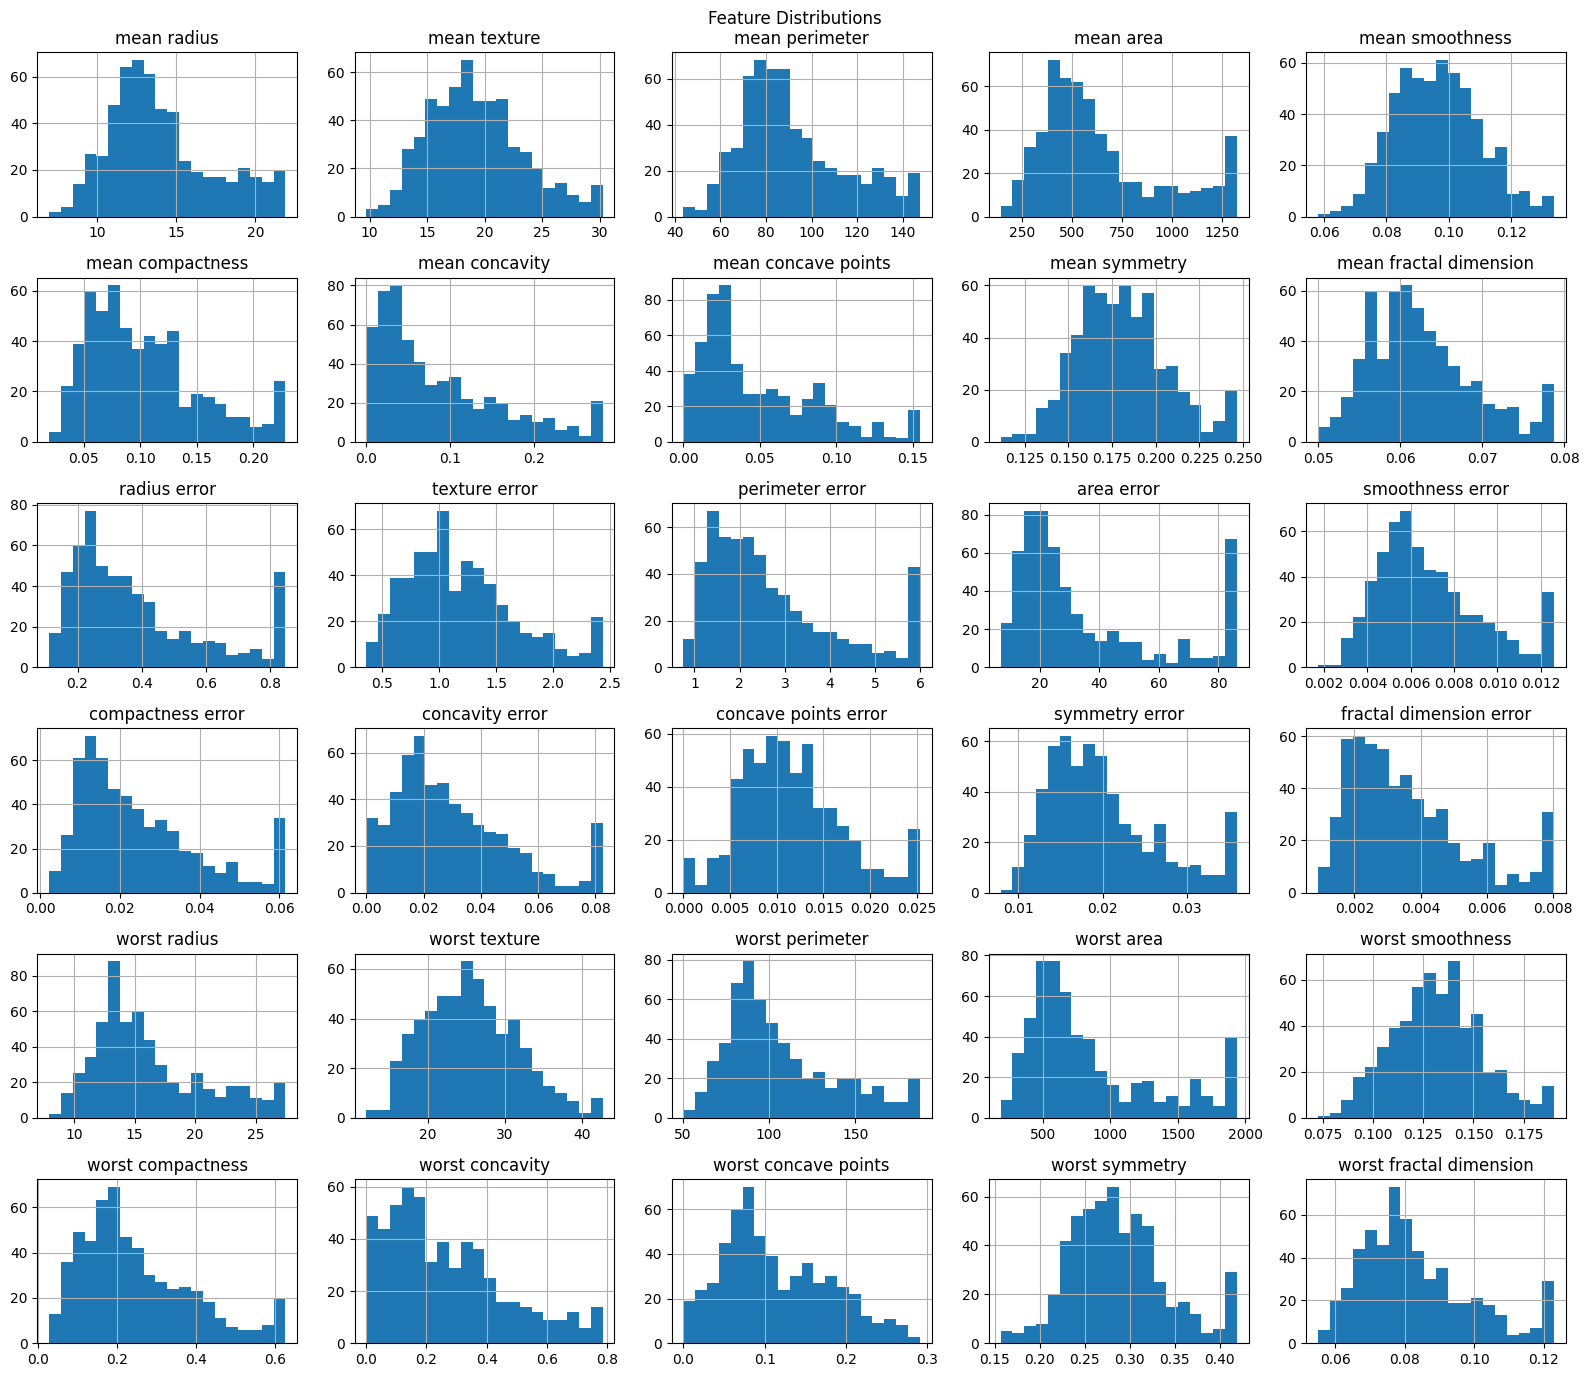

In [17]:
df_clean.drop(
    columns="Outcome"
).hist(
    figsize=(16, 14),
    bins=20
)

plt.suptitle(
    "Feature Distributions"
)

plt.tight_layout()
plt.show()

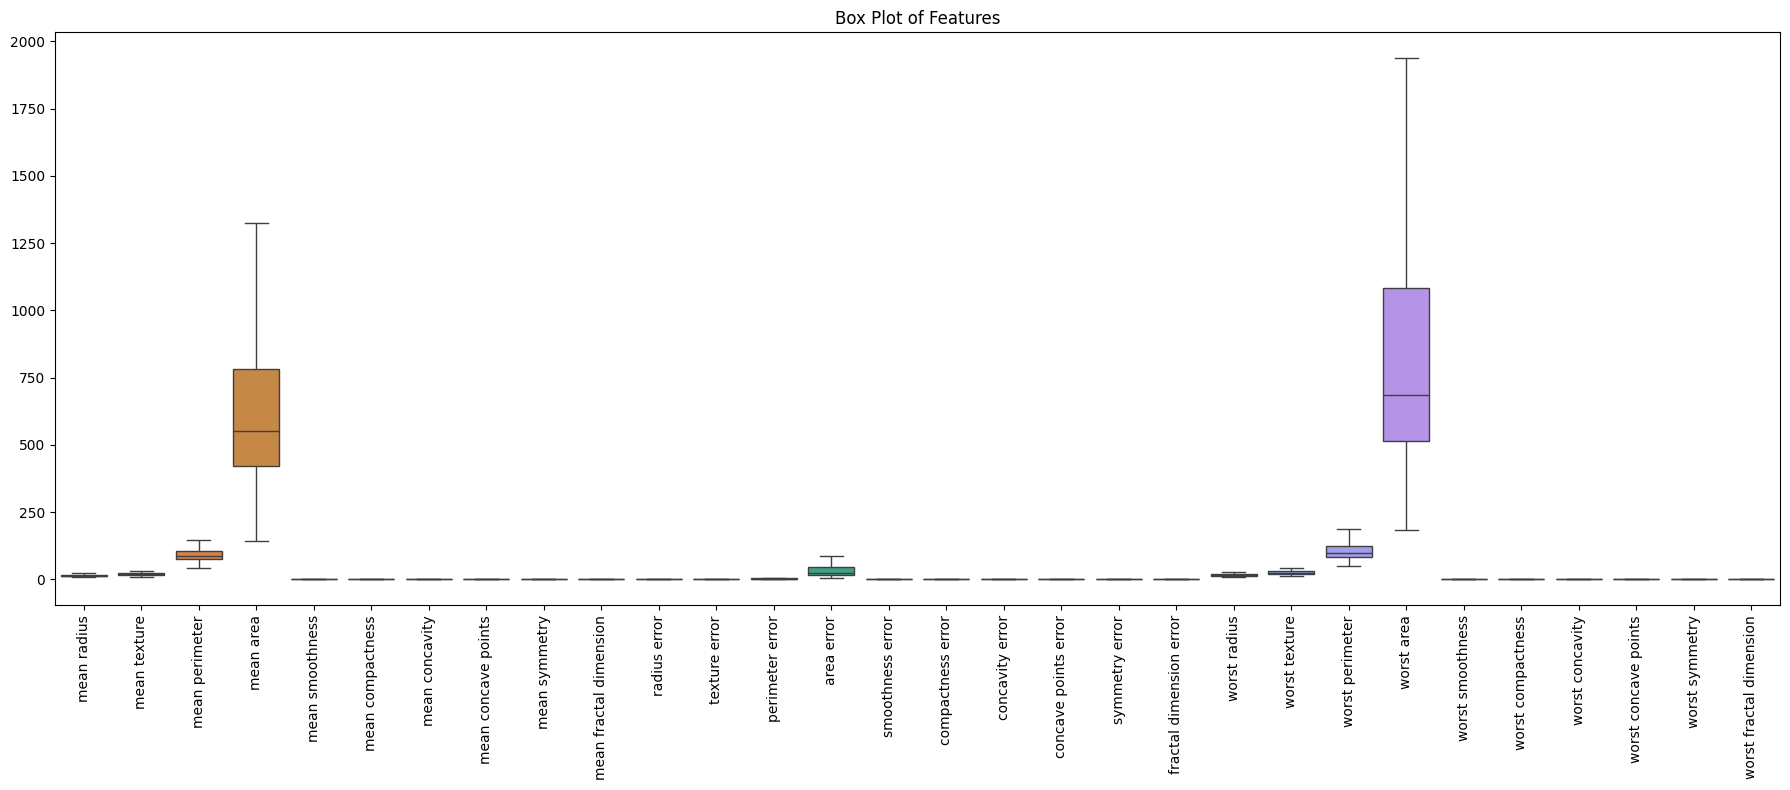

In [18]:
plt.figure(
    figsize=(18, 8)
)

sns.boxplot(
    data=df_clean.drop(columns="Outcome")
)

plt.title(
    "Box Plot of Features"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()
plt.show()

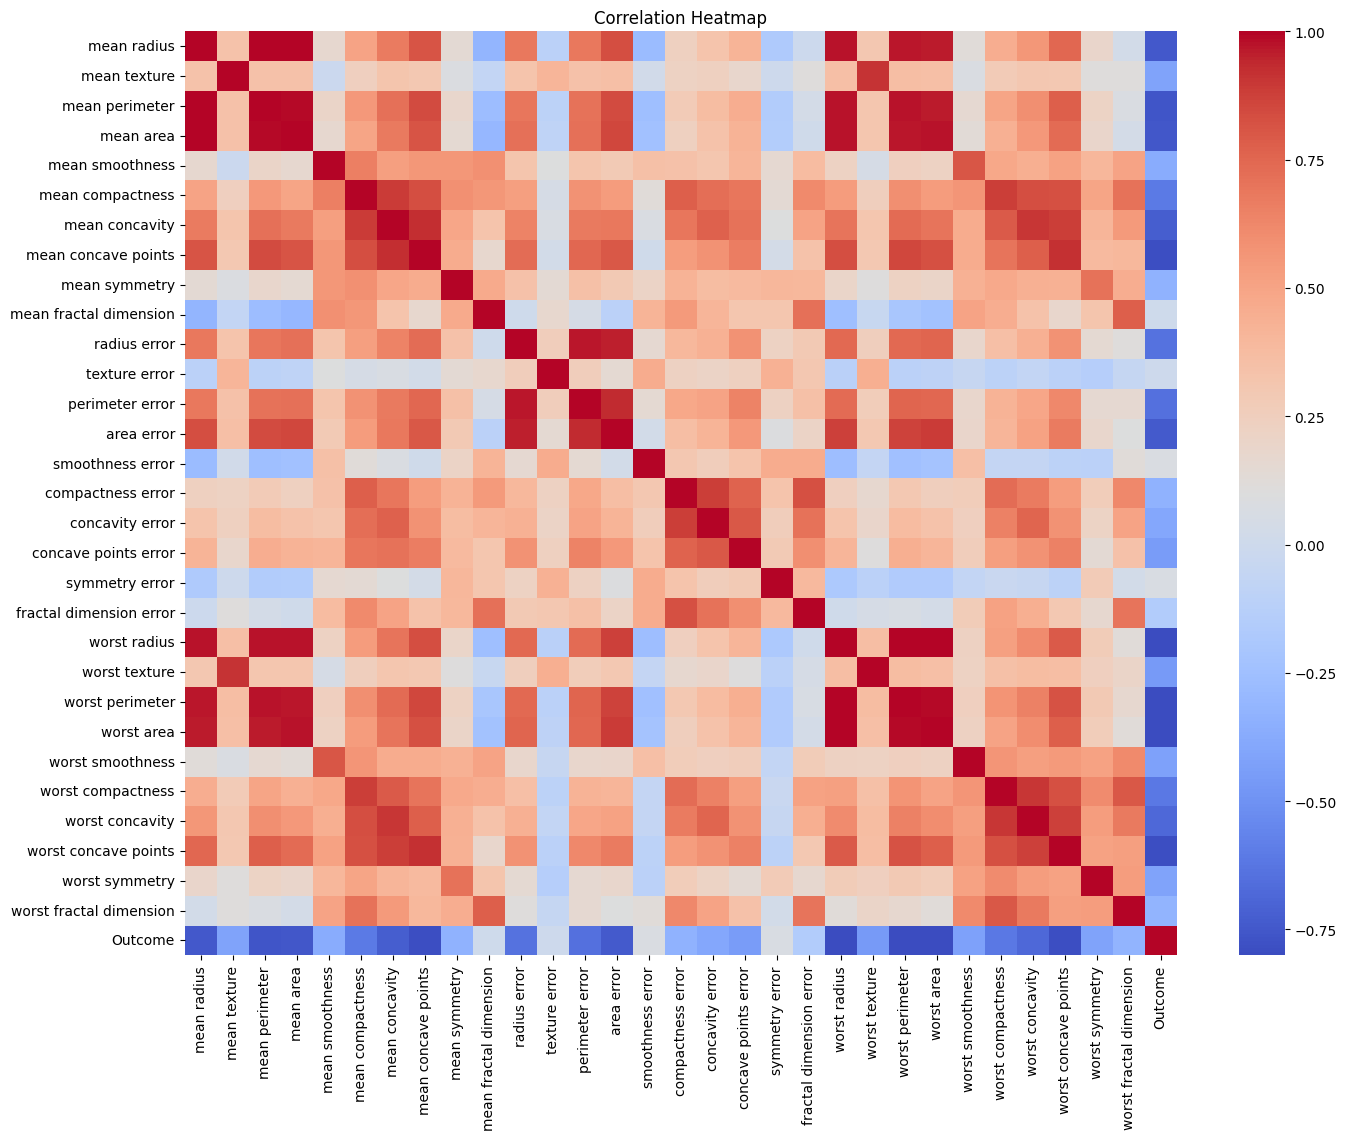

In [19]:
plt.figure(
    figsize=(16, 12)
)

sns.heatmap(
    df_clean.corr(),
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [20]:
print("Class distribution:")

display(
    df_clean["Outcome"].value_counts()
)

Class distribution:


,count
Outcome,
1,357
0,212


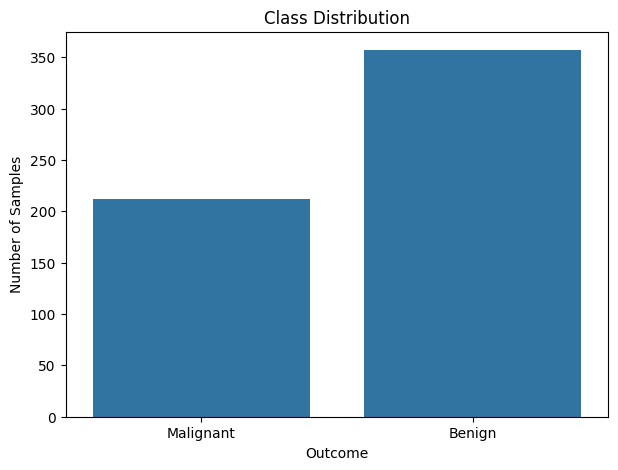

In [21]:
plt.figure(
    figsize=(7, 5)
)

sns.countplot(
    data=df_clean,
    x="Outcome"
)

plt.title(
    "Class Distribution"
)

plt.xlabel(
    "Outcome"
)

plt.ylabel(
    "Number of Samples"
)

plt.xticks(
    [0, 1],
    ["Malignant", "Benign"]
)

plt.show()

In [22]:
class_percentage = (
    df_clean["Outcome"]
    .value_counts(normalize=True)
    * 100
)

print("Class percentages:")
display(class_percentage)

Class percentages:


,proportion
Outcome,
1,62.741652
0,37.258348


In [23]:
print("""
The dataset contains two classes: malignant and benign.

If the class sizes are different, the dataset has class
imbalance. Class imbalance can cause a model to favor the
majority class.

For medical diagnosis, accuracy alone is not enough.
Precision, recall, F1-score and ROC-AUC should also be
considered.
""")


The dataset contains two classes: malignant and benign.

If the class sizes are different, the dataset has class
imbalance. Class imbalance can cause a model to favor the
majority class.

For medical diagnosis, accuracy alone is not enough.
Precision, recall, F1-score and ROC-AUC should also be
considered.



In [24]:
print("""
The dataset contains two classes: malignant and benign.

If the class sizes are different, the dataset has class
imbalance. Class imbalance can cause a model to favor the
majority class.

For medical diagnosis, accuracy alone is not enough.
Precision, recall, F1-score and ROC-AUC should also be
considered.
""")


The dataset contains two classes: malignant and benign.

If the class sizes are different, the dataset has class
imbalance. Class imbalance can cause a model to favor the
majority class.

For medical diagnosis, accuracy alone is not enough.
Precision, recall, F1-score and ROC-AUC should also be
considered.



In [25]:
y = y.astype(int)

print(
    "Target classes:",
    sorted(y.unique())
)

print("0 = Malignant")
print("1 = Benign")

Target classes: [np.int64(0), np.int64(1)]
0 = Malignant
1 = Benign


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training data:",
    X_train.shape
)

print(
    "Testing data:",
    X_test.shape
)

Training data: (455, 30)
Testing data: (114, 30)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training data:",
    X_train.shape
)

print(
    "Testing data:",
    X_test.shape
)

Training data: (455, 30)
Testing data: (114, 30)


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Features standardized successfully")

Features standardized successfully


In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Features standardized successfully")

Features standardized successfully


In [30]:
y_pred = model.predict(
    X_test_scaled
)

y_prob = model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predictions generated")

Predictions generated


In [31]:
y_pred = model.predict(
    X_test_scaled
)

y_prob = model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predictions generated")

Predictions generated


In [32]:
precision = precision_score(
    y_test,
    y_pred,
    average=None
)

print(
    "Precision - Malignant:",
    round(precision[0], 4)
)

print(
    "Precision - Benign:",
    round(precision[1], 4)
)

Precision - Malignant: 1.0
Precision - Benign: 0.9863


In [33]:
recall = recall_score(
    y_test,
    y_pred,
    average=None
)

print(
    "Recall - Malignant:",
    round(recall[0], 4)
)

print(
    "Recall - Benign:",
    round(recall[1], 4)
)

Recall - Malignant: 0.9762
Recall - Benign: 1.0


In [34]:
recall = recall_score(
    y_test,
    y_pred,
    average=None
)

print(
    "Recall - Malignant:",
    round(recall[0], 4)
)

print(
    "Recall - Benign:",
    round(recall[1], 4)
)

Recall - Malignant: 0.9762
Recall - Benign: 1.0


In [35]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Malignant",
            "Benign"
        ]
    )
)

              precision    recall  f1-score   support

   Malignant       1.00      0.98      0.99        42
      Benign       0.99      1.00      0.99        72

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



In [36]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[41  1]
 [ 0 72]]


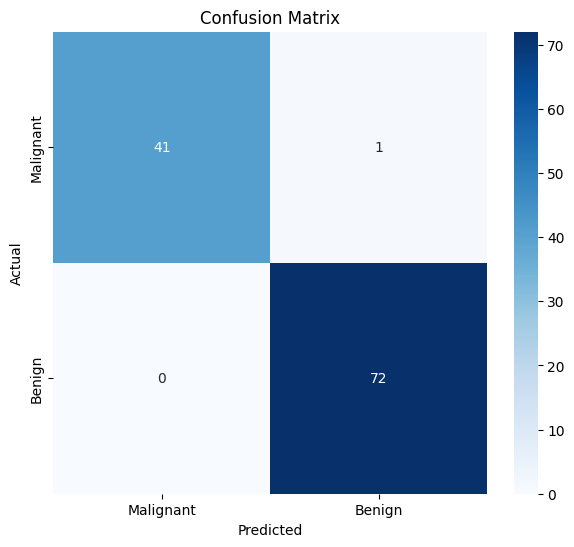

In [37]:
plt.figure(
    figsize=(7, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Malignant",
        "Benign"
    ],
    yticklabels=[
        "Malignant",
        "Benign"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [38]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print(
    "AUC Score:",
    round(auc_score, 4)
)

AUC Score: 0.9954


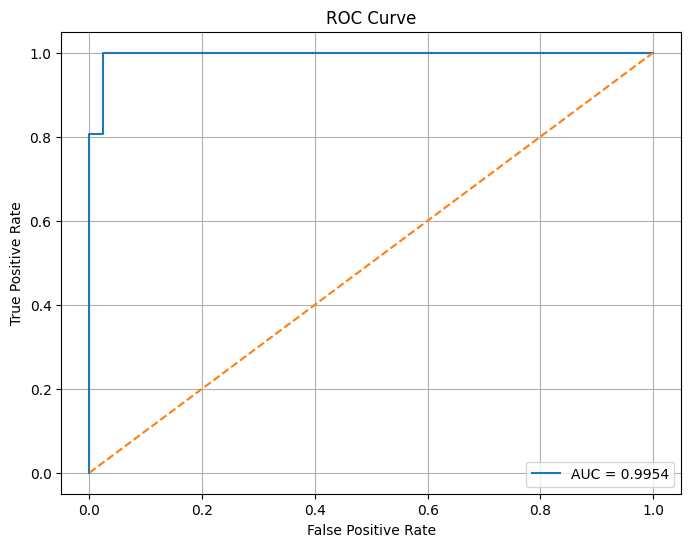

In [39]:
plt.figure(
    figsize=(8, 6)
)

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.grid()

plt.show()

In [40]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute",
    ascending=False
)

display(
    coefficients.head(10)
)

,Feature,Coefficient,Absolute
21,worst texture,-1.215472,1.215472
13,area error,-1.149581,1.149581
15,compactness error,1.006546,1.006546
28,worst symmetry,-0.913640,0.913640
27,worst concave points,-0.897069,0.897069
23,worst area,-0.869331,0.869331
24,worst smoothness,-0.804356,0.804356
20,worst radius,-0.769020,0.769020
26,worst concavity,-0.751742,0.751742
10,radius error,-0.751739,0.751739


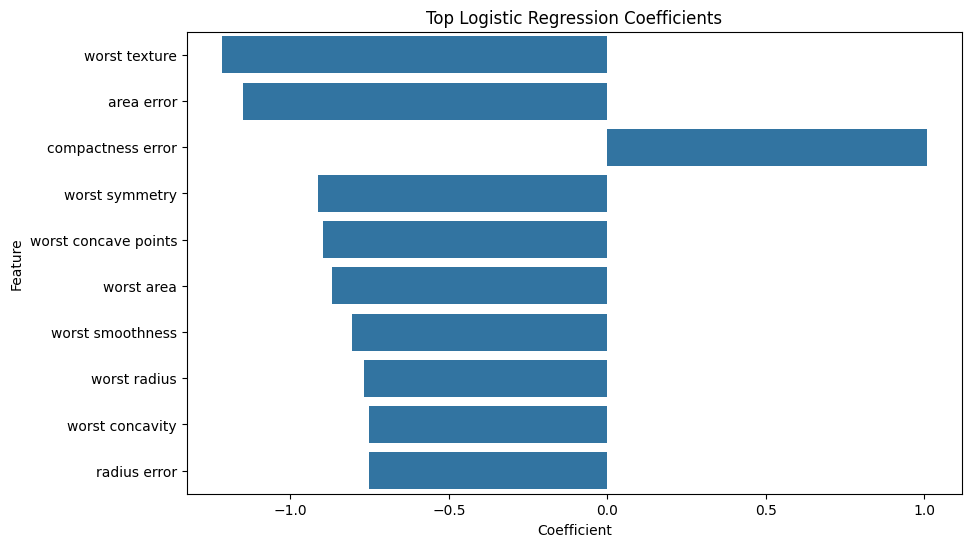

In [41]:
top_features = coefficients.head(10)

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Top Logistic Regression Coefficients"
)

plt.show()

In [42]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision - Malignant",
        "Precision - Benign",
        "Recall - Malignant",
        "Recall - Benign",
        "F1 - Malignant",
        "F1 - Benign",
        "ROC-AUC"
    ],

    "Score": [
        accuracy,
        precision[0],
        precision[1],
        recall[0],
        recall[1],
        f1[0],
        f1[1],
        auc_score
    ]
})

results["Score"] = results["Score"].round(4)

display(results)

,Metric,Score
0,Accuracy,0.9825
1,Precision - Malignant,1.0000
2,Precision - Benign,0.9863
3,Recall - Malignant,0.9762
4,Recall - Benign,1.0000
5,F1 - Malignant,0.9762
6,F1 - Benign,0.9861
7,ROC-AUC,0.9954


In [43]:
print("""
Interpretation:

Accuracy shows the overall percentage of correct predictions.

Precision shows how reliable the predictions are for each class.

Recall shows how many actual cases from each class were
correctly identified.

F1-score combines precision and recall.

The confusion matrix shows true and false predictions for
malignant and benign cases.

ROC-AUC measures how well the model separates the two classes.

In medical diagnosis, recall is particularly important because
missing a malignant case can have serious consequences.

Therefore, the model should not be evaluated using accuracy
alone.

This model is intended for educational purposes and should not
replace professional medical diagnosis.
""")


Interpretation:

Accuracy shows the overall percentage of correct predictions.

Precision shows how reliable the predictions are for each class.

Recall shows how many actual cases from each class were
correctly identified.

F1-score combines precision and recall.

The confusion matrix shows true and false predictions for
malignant and benign cases.

ROC-AUC measures how well the model separates the two classes.

In medical diagnosis, recall is particularly important because
missing a malignant case can have serious consequences.

Therefore, the model should not be evaluated using accuracy
alone.

This model is intended for educational purposes and should not
replace professional medical diagnosis.

